In [4]:
#Using U-Model code from Module 3 notebook

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [7]:
#Defining U-Net building blocks
#Convolution Block
def conv_block(inputs, filters):
    x = layers.Conv2D(filters, 3, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    return x

In [8]:
#Encoder Block
def encoder_block(inputs, filters):
    x = conv_block(inputs, filters)
    p = layers.MaxPooling2D((2, 2))(x)
    return x, p

In [9]:
#Decoder Block
def decoder_block(inputs, skip_features, filters):
    x = layers.Conv2DTranspose(filters, (2, 2), strides=2, padding="same")(inputs)
    x = layers.Concatenate()([x, skip_features])
    x = conv_block(x, filters)
    return x

In [10]:
#Building SAR specific U-Net Model
def build_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bottleneck
    b1 = conv_block(p4, 1024)

    # Decoder
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    # Output layer (binary segmentation)
    outputs = layers.Conv2D(1, 1, padding="same", activation="sigmoid")(d4)

    model = models.Model(inputs, outputs, name="U-Net_SAR")

    return model

In [11]:
model = build_unet()
model.summary()

Model: "U-Net_SAR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ re_lu_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,054,145 (118.46 MB)

 Trainable params: 31,042,369 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [12]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [13]:
#Model Training

In [14]:
import os
import cv2
import numpy as np

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split

In [15]:
IMAGE_DIR = r"oil_spill_dataset/train/images"
MASK_DIR  = r"oil_spill_dataset/train/masks"

image_files = sorted([
    os.path.join(IMAGE_DIR, f)
    for f in os.listdir(IMAGE_DIR)
])

mask_files = sorted([
    os.path.join(MASK_DIR, f)
    for f in os.listdir(MASK_DIR)
])

print(len(image_files), len(mask_files))

5487 5487


In [16]:
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_files,
    mask_files,
    test_size=0.15,
    random_state=42
)

In [17]:
def data_generator(image_files, mask_files, batch_size, img_size):
    while True:
        for i in range(0, len(image_files), batch_size):

            batch_imgs = image_files[i:i+batch_size]
            batch_msks = mask_files[i:i+batch_size]

            if len(batch_imgs) < batch_size:
                continue

            images = np.zeros((batch_size, img_size, img_size, 1), dtype=np.float32)
            masks  = np.zeros((batch_size, img_size, img_size, 1), dtype=np.float32)

            for j, (img_path, mask_path) in enumerate(zip(batch_imgs, batch_msks)):
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

                if img is None or mask is None:
                    continue

                img = cv2.resize(img, (img_size, img_size))
                mask = cv2.resize(mask, (img_size, img_size))

                images[j, ..., 0] = img / 255.0
                masks[j, ..., 0]  = (mask > 127).astype(np.float32)

            yield images, masks

In [18]:
BATCH_SIZE = 4

train_gen = data_generator(train_imgs, train_masks, BATCH_SIZE, 256)
val_gen   = data_generator(val_imgs, val_masks, BATCH_SIZE, 256)

In [19]:
IMG_SIZE = 256
EPOCHS = 5

steps_per_epoch = 100      
validation_steps = 25     

In [20]:
#defining loss fucntions

In [31]:
#1. Dice coefficient
import tensorflow as tf
from tensorflow.keras import backend as K
from keras.saving import register_keras_serializable

@register_keras_serializable()
def dice_coefficient(y_true, y_pred, smooth=1):
    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)
    intersection = K.sum(y_true * y_pred)
    return (2. * intersection + smooth) / (K.sum(y_true) + K.sum(y_pred) + smooth)

In [32]:
#2. Dice Loss
@register_keras_serializable()
def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

In [33]:
#3. Combined Loss
@register_keras_serializable()
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

In [34]:
#Defining Evaluation Metrics
@register_keras_serializable()
def iou_score(y_true, y_pred, smooth=1):
    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)
    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

In [25]:
#recompiling the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[
        "accuracy",
        dice_coefficient,
        iou_score,
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [35]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=100,
    validation_steps=25,
    epochs=5
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 686s 7s/step - accuracy: 0.8884 - dice_coefficient: 0.6788 - iou_score: 0.5270 - loss: 0.6075 - precision: 0.7537 - recall: 0.7745 - val_accuracy: 0.8509 - val_dice_coefficient: 0.6247 - val_iou_score: 0.4614 - val_loss: 0.7200 - val_precision: 0.6571 - val_recall: 0.8075
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 676s 7s/step - accuracy: 0.8655 - dice_coefficient: 0.6919 - iou_score: 0.5396 - loss: 0.6252 - precision: 0.7587 - recall: 0.7452 - val_accuracy: 0.9130 - val_dice_coefficient: 0.7096 - val_iou_score: 0.5557 - val_loss: 0.5258 - val_precision: 0.8377 - val_recall: 0.8504
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 724s 7s/step - accuracy: 0.8881 - dice_coefficient: 0.6928 - iou_score: 0.5427 - loss: 0.5898 - precision: 0.7602 - recall: 0.7883 - val_accuracy: 0.9151 - val_dice_coefficient: 0.7187 - val_iou_score: 0.5713 - val_loss: 0.5017 - val_precision: 0.8061 - val_recall: 0.8544
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 683s 7s/step - accuracy: 

In [36]:
model.save("oil_spill_segmentation_unet.keras")

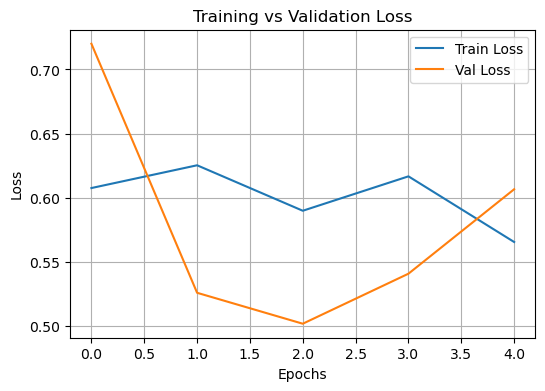

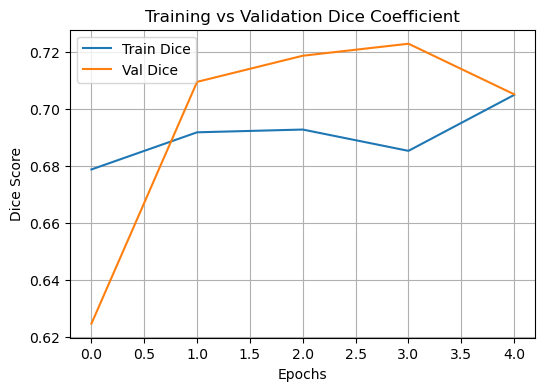

In [37]:
# Training Curves 
import matplotlib.pyplot as plt

def plot_training_curves(history):
    # Loss
    plt.figure(figsize=(6,4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()

    # Dice
    plt.figure(figsize=(6,4))
    plt.plot(history.history['dice_coefficient'], label='Train Dice')
    plt.plot(history.history['val_dice_coefficient'], label='Val Dice')
    plt.title('Training vs Validation Dice Coefficient')
    plt.xlabel('Epochs')
    plt.ylabel('Dice Score')
    plt.legend()
    plt.grid()
    plt.show()

plot_training_curves(history)


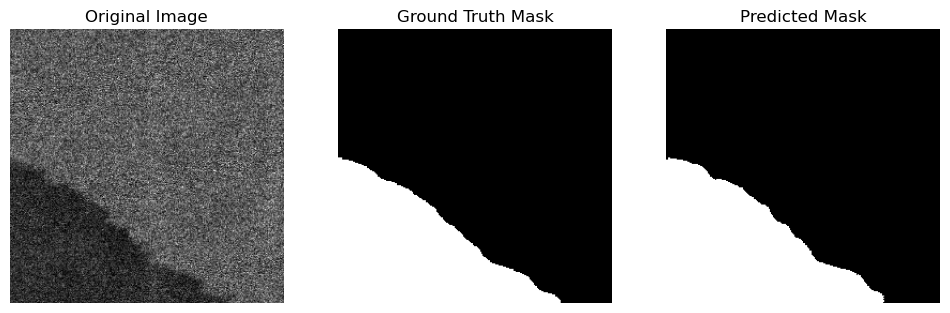

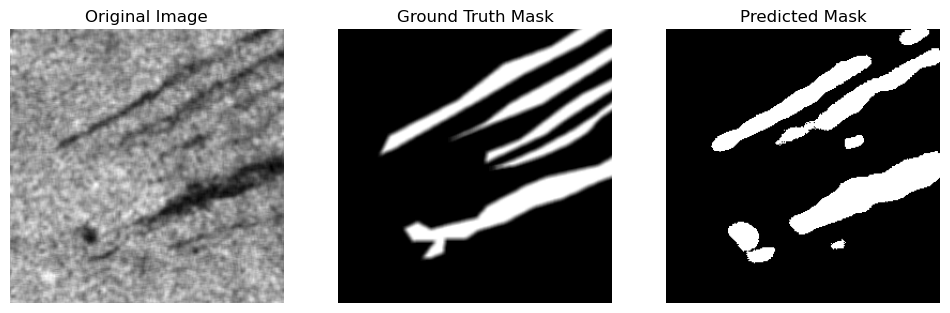

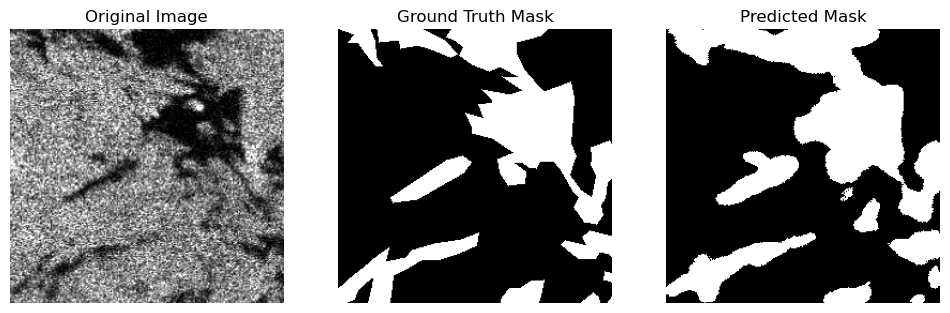

In [38]:
#Prediction Visualization
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_predictions(model, image_paths, mask_paths, img_size=256, num_samples=3):
    import random
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt

    indices = random.sample(range(len(image_paths)), num_samples)

    for i in indices:
        # ---- IMAGE (GRAYSCALE, 1 CHANNEL) ----
        img = cv2.imread(image_paths[i], cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (img_size, img_size))
        img = img / 255.0
        img = np.expand_dims(img, axis=-1)  

        # ---- MASK ----
        mask = cv2.imread(mask_paths[i], cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (img_size, img_size))
        mask = mask / 255.0

        # ---- PREDICTION ----
        pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
        pred = (pred > 0.5).astype(np.uint8)

        # ---- DISPLAY ----
        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(mask, cmap='gray')
        plt.title("Ground Truth Mask")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(pred.squeeze(), cmap='gray')
        plt.title("Predicted Mask")
        plt.axis("off")

        plt.show()

visualize_predictions(model, val_imgs, val_masks)

In [39]:
#Hyperparameter Tuning Summary

#The following hyperparameters were tuned based on validation performance:

#- Image size: 256 × 256 (trade-off between accuracy & training time)
#- Batch size: 4 (GPU/CPU memory safe)
#- Learning rate: 1e-4 (stable Dice convergence)
#- Epochs: 5 (initial training to avoid overfitting)
#- Loss function: Dice Loss + Binary Cross Entropy
#- Optimizer: Adam

#Future tuning includes:
#- Learning rate scheduler
#- Increased epochs with early stopping
#- Stronger data augmentation